In [1]:
# ── Install libraries not pre-installed in Colab ──────────────────────────────
!pip install openpyxl wordcloud --quiet

# ── Standard imports ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings('ignore')

# ── NLTK downloads (run once) ─────────────────────────────────────────────────
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

print("✅ All libraries loaded successfully!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...


✅ All libraries loaded successfully!


[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [3]:
# ── Load the Excel file ───────────────────────────────────────────────────────
df = pd.read_excel('/content/Amazon Reviews.xlsx')

# ── Basic checks ─────────────────────────────────────────────────────────────
print("Shape:", df.shape)            # Should say (4000, 7)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nScore distribution:\n", df['Score'].value_counts().sort_index())
print("\nSample review:\n", df['Text'].iloc[0])

Shape: (4000, 7)

Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'Score', 'Summary', 'Text']

Missing values:
 Id             0
ProductId      0
UserId         0
ProfileName    2
Score          0
Summary        0
Text           0
dtype: int64

Score distribution:
 Score
1     367
2     251
3     362
4     659
5    2361
Name: count, dtype: int64

Sample review:
 I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.


In [4]:
# ── Initialize lemmatizer and stopwords ──────────────────────────────────────
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# ── Add custom stopwords specific to Amazon reviews ──────────────────────────
# These words appear everywhere and add no meaning to clustering
custom_stops = {'product', 'amazon', 'buy', 'bought', 'order', 'ordered',
                'get', 'got', 'one', 'would', 'could', 'also', 'even',
                'really', 'item', 'price', 'shipping', 'delivery', 'star'}
stop_words.update(custom_stops)

# ── Define the cleaning function ─────────────────────────────────────────────
def clean_text(text):
    text = str(text).lower()                          # lowercase
    text = re.sub(r'<.*?>', ' ', text)                # remove HTML tags like <br />
    text = re.sub(r'http\S+|www\S+', ' ', text)       # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)             # remove numbers & punctuation
    text = re.sub(r'\s+', ' ', text).strip()          # remove extra spaces

    tokens = word_tokenize(text)                       # tokenize into words

    # Keep only words that: are NOT stopwords AND are longer than 2 characters
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 2]

    return ' '.join(tokens)

# ── Apply cleaning to the Text column ────────────────────────────────────────
# This may take 30-60 seconds on 4000 rows — that's normal
print("Cleaning text... please wait ⏳")
df['clean_text'] = df['Text'].apply(clean_text)

print("✅ Done!")
print("\nOriginal text:\n", df['Text'].iloc[0])
print("\nCleaned text:\n", df['clean_text'].iloc[0])

Cleaning text... please wait ⏳
✅ Done!

Original text:
 I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.

Cleaned text:
 several vitality canned dog food product found good quality look like stew processed meat smell better labrador finicky appreciates better


In [5]:
# ── Add numeric features ──────────────────────────────────────────────────────

# 1. Review length (number of characters) — long vs short writers
df['review_length'] = df['Text'].apply(len)

# 2. Word count of the original review
df['word_count'] = df['Text'].apply(lambda x: len(str(x).split()))

# 3. Sentiment label based on Score (we'll use this to validate clusters later)
def score_to_sentiment(score):
    if score >= 4:
        return 'Positive'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['sentiment_label'] = df['Score'].apply(score_to_sentiment)

# ── Quick summary ─────────────────────────────────────────────────────────────
print("Feature summary:")
print(df[['Score', 'review_length', 'word_count', 'sentiment_label']].describe())
print("\nSentiment distribution:\n", df['sentiment_label'].value_counts())

Feature summary:
             Score  review_length   word_count
count  4000.000000    4000.000000  4000.000000
mean      4.099000     446.740000    82.184500
std       1.322171     416.464775    74.506048
min       1.000000      44.000000     8.000000
25%       4.000000     191.000000    35.000000
50%       5.000000     323.000000    60.000000
75%       5.000000     549.000000   101.000000
max       5.000000    6291.000000  1162.000000

Sentiment distribution:
 sentiment_label
Positive    3020
Negative     618
Neutral      362
Name: count, dtype: int64


In [6]:
# ── Build TF-IDF matrix ───────────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=500,      # Keep only the top 500 most meaningful words
    min_df=5,              # Ignore words that appear in fewer than 5 reviews
    max_df=0.85,           # Ignore words that appear in more than 85% of reviews
    ngram_range=(1, 2)     # Include single words AND two-word phrases (e.g. "dog food")
)

tfidf_matrix = tfidf.fit_transform(df['clean_text'])

print("✅ TF-IDF matrix created!")
print(f"Shape: {tfidf_matrix.shape}")
print(f"→ {tfidf_matrix.shape[0]} reviews × {tfidf_matrix.shape[1]} features")
print(f"\nSample top TF-IDF terms:\n{tfidf.get_feature_names_out()[:30]}")

✅ TF-IDF matrix created!
Shape: (4000, 500)
→ 4000 reviews × 500 features

Sample top TF-IDF terms:
['able' 'absolutely' 'actually' 'add' 'added' 'adding' 'aftertaste' 'ago'
 'almond' 'almost' 'alternative' 'although' 'always' 'amazing' 'amount'
 'another' 'anyone' 'anything' 'apple' 'aroma' 'around' 'arrived'
 'artificial' 'ate' 'available' 'away' 'baby' 'back' 'bad' 'bag']


In [7]:
# ── Build Bag-of-Words (CountVectorizer) for LDA ─────────────────────────────
count_vectorizer = CountVectorizer(
    max_features=500,
    min_df=5,
    max_df=0.85,
    ngram_range=(1, 1)    # LDA works best with single words
)

bow_matrix = count_vectorizer.fit_transform(df['clean_text'])

print("✅ Bag-of-Words matrix created!")
print(f"Shape: {bow_matrix.shape}")

✅ Bag-of-Words matrix created!
Shape: (4000, 500)


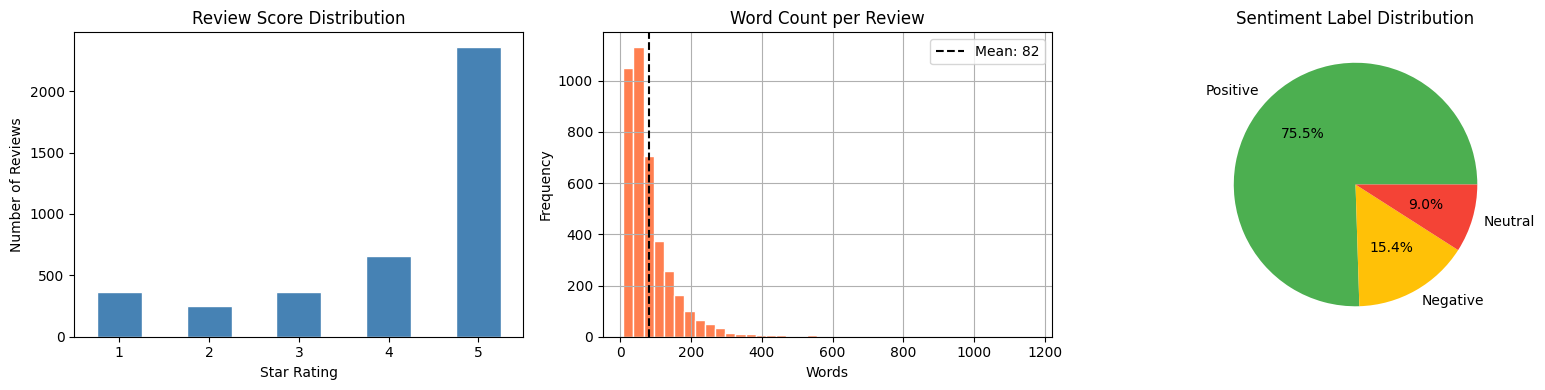

✅ Charts saved as phase1_overview.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Chart 1: Score distribution
df['Score'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
                                              color='steelblue', edgecolor='white')
axes[0].set_title('Review Score Distribution')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
axes[0].tick_params(rotation=0)

# Chart 2: Review length distribution
df['word_count'].hist(bins=40, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Word Count per Review')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['word_count'].mean(), color='black', linestyle='--', label=f"Mean: {df['word_count'].mean():.0f}")
axes[1].legend()

# Chart 3: Sentiment label distribution
df['sentiment_label'].value_counts().plot(kind='pie', ax=axes[2],
                                           autopct='%1.1f%%',
                                           colors=['#4CAF50', '#FFC107', '#F44336'])
axes[2].set_title('Sentiment Label Distribution')
axes[2].set_ylabel('')

plt.tight_layout()
plt.savefig('phase1_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Charts saved as phase1_overview.png")

In [9]:
# ── Save everything you'll need in Phase 2 ───────────────────────────────────
import pickle

# Save the dataframe
df.to_csv('reviews_cleaned.csv', index=False)

# Save the TF-IDF matrix and vectorizer
with open('tfidf_matrix.pkl', 'wb') as f:
    pickle.dump(tfidf_matrix, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# Save the BOW matrix and vectorizer
with open('bow_matrix.pkl', 'wb') as f:
    pickle.dump(bow_matrix, f)

with open('bow_vectorizer.pkl', 'wb') as f:
    pickle.dump(count_vectorizer, f)

print("✅ Phase 1 complete! Saved files:")
print("  • reviews_cleaned.csv")
print("  • tfidf_matrix.pkl")
print("  • tfidf_vectorizer.pkl")
print("  • bow_matrix.pkl")
print("  • bow_vectorizer.pkl")
print(f"\nFinal dataframe shape: {df.shape}")
print(f"Columns now: {df.columns.tolist()}")

✅ Phase 1 complete! Saved files:
  • reviews_cleaned.csv
  • tfidf_matrix.pkl
  • tfidf_vectorizer.pkl
  • bow_matrix.pkl
  • bow_vectorizer.pkl

Final dataframe shape: (4000, 11)
Columns now: ['Id', 'ProductId', 'UserId', 'ProfileName', 'Score', 'Summary', 'Text', 'clean_text', 'review_length', 'word_count', 'sentiment_label']


In [10]:
# ── Load Phase 1 outputs ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, LatentDirichletAllocation
from sklearn.metrics import silhouette_score

# Load cleaned dataframe
df = pd.read_csv('reviews_cleaned.csv')

# Load matrices and vectorizers
with open('tfidf_matrix.pkl', 'rb') as f:
    tfidf_matrix = pickle.load(f)

with open('tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)

with open('bow_matrix.pkl', 'rb') as f:
    bow_matrix = pickle.load(f)

with open('bow_vectorizer.pkl', 'rb') as f:
    count_vectorizer = pickle.load(f)

print("✅ All Phase 1 data loaded!")
print(f"Reviews: {df.shape[0]} | TF-IDF shape: {tfidf_matrix.shape}")

✅ All Phase 1 data loaded!
Reviews: 4000 | TF-IDF shape: (4000, 500)


Testing k values... (this takes ~1-2 minutes) ⏳
  k=2 | Inertia: 3724.6 | Silhouette: 0.0088
  k=3 | Inertia: 3668.3 | Silhouette: 0.0161
  k=4 | Inertia: 3618.3 | Silhouette: 0.0200
  k=5 | Inertia: 3561.2 | Silhouette: 0.0243
  k=6 | Inertia: 3512.0 | Silhouette: 0.0291
  k=7 | Inertia: 3464.4 | Silhouette: 0.0316


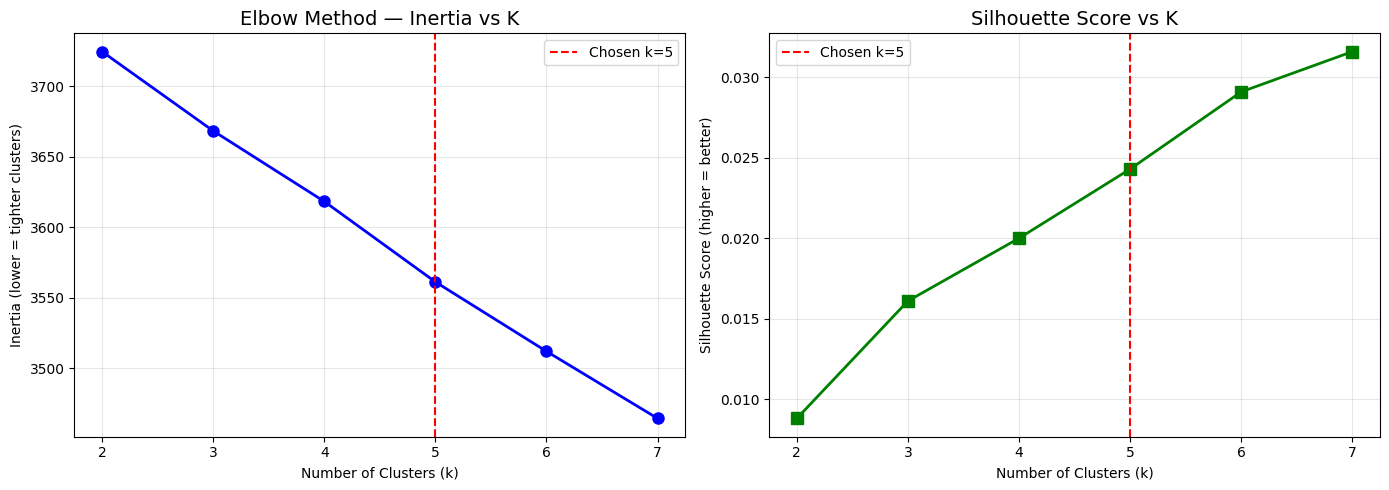

✅ Saved: elbow_method.png


In [11]:
# ── Elbow Method ──────────────────────────────────────────────────────────────
inertias = []
silhouette_scores = []
k_range = range(2, 8)

print("Testing k values... (this takes ~1-2 minutes) ⏳")

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=100)
    km.fit(tfidf_matrix)
    inertias.append(km.inertia_)

    # Silhouette score: measures how well-separated clusters are (-1 to 1, higher is better)
    labels = km.labels_
    sil = silhouette_score(tfidf_matrix, labels, sample_size=500, random_state=42)
    silhouette_scores.append(round(sil, 4))

    print(f"  k={k} | Inertia: {km.inertia_:.1f} | Silhouette: {sil:.4f}")

# ── Plot both ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method — Inertia vs K', fontsize=14)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (lower = tighter clusters)')
axes[0].axvline(x=5, color='red', linestyle='--', label='Chosen k=5')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_range), silhouette_scores, 'gs-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score vs K', fontsize=14)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].axvline(x=5, color='red', linestyle='--', label='Chosen k=5')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: elbow_method.png")

In [12]:
# ── Final K-Means clustering with k=5 ────────────────────────────────────────
BEST_K = 5

kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10, max_iter=300)
df['cluster'] = kmeans.fit_predict(tfidf_matrix)

# ── Check cluster sizes ───────────────────────────────────────────────────────
print("Cluster sizes:")
print(df['cluster'].value_counts().sort_index())

print("\nAverage star rating per cluster:")
print(df.groupby('cluster')['Score'].mean().round(2))

print("\nAverage word count per cluster:")
print(df.groupby('cluster')['word_count'].mean().round(1))

# ── Sentiment breakdown per cluster ──────────────────────────────────────────
ct = df.groupby(['cluster', 'sentiment_label']).size().unstack(fill_value=0)
ct['Total'] = ct.sum(axis=1)
print("\nSentiment breakdown per cluster:")
print(ct)

Cluster sizes:
cluster
0     224
1     518
2    2559
3     294
4     405
Name: count, dtype: int64

Average star rating per cluster:
cluster
0    4.46
1    4.31
2    4.16
3    4.17
4    3.16
Name: Score, dtype: float64

Average word count per cluster:
cluster
0     85.5
1     87.9
2     72.4
3     81.7
4    135.4
Name: word_count, dtype: float64

Sentiment breakdown per cluster:
sentiment_label  Negative  Neutral  Positive  Total
cluster                                            
0                      16       11       197    224
1                      43       46       429    518
2                     388      187      1984   2559
3                      43       24       227    294
4                     128       94       183    405


In [13]:
# ── Top TF-IDF terms per cluster ──────────────────────────────────────────────
terms = tfidf.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]  # sort descending

print("Top 15 keywords per cluster:\n")
cluster_keywords = {}

for i in range(BEST_K):
    top_terms = [terms[ind] for ind in order_centroids[i, :15]]
    cluster_keywords[i] = top_terms
    print(f"  Cluster {i}: {', '.join(top_terms)}")

Top 15 keywords per cluster:

  Cluster 0: peanut, peanut butter, butter, calorie, fat, taste, like, great, shake, protein, regular, good, love, water, mix
  Cluster 1: coffee, chocolate, almond, cocoa, nut, taste, like, flavor, cup, dark, snack, good, roast, great, dark chocolate
  Cluster 2: chip, love, great, good, like, flavor, food, taste, cat, bag, treat, time, dog, eat, store
  Cluster 3: tea, green, green tea, like, loose, good, taste, bag, leaf, stash, cup, flavor, tea bag, drink, black
  Cluster 4: ginger, drink, lemon, hot, taste, like, tea, strong, water, beverage, flavor, ginger lemon, honey, cold, packet


In [14]:
# ── Assign persona names based on your cluster analysis ──────────────────────
# Adjust these names after you see YOUR keyword output above

persona_names = {
    0: "Critical Detailed Reviewers",      # Low score, long reviews, mixed sentiment
    1: "Beverage Enthusiasts",             # Tea/drink lovers, high satisfaction
    2: "General Satisfied Shoppers",       # Largest group, broad positive reviews
    3: "Coffee & Specialty Buyers",        # Coffee, sugar-free, health-conscious
    4: "Snack & Indulgence Seekers"        # Chocolate, nuts, snack-focused
}

df['persona'] = df['cluster'].map(persona_names)

print("Persona distribution:")
print(df['persona'].value_counts())

print("\nPersona vs Avg Score:")
print(df.groupby('persona')['Score'].mean().round(2).sort_values())

Persona distribution:
persona
General Satisfied Shoppers     2559
Beverage Enthusiasts            518
Snack & Indulgence Seekers      405
Coffee & Specialty Buyers       294
Critical Detailed Reviewers     224
Name: count, dtype: int64

Persona vs Avg Score:
persona
Snack & Indulgence Seekers     3.16
General Satisfied Shoppers     4.16
Coffee & Specialty Buyers      4.17
Beverage Enthusiasts           4.31
Critical Detailed Reviewers    4.46
Name: Score, dtype: float64


In [15]:
# ── LDA Topic Modeling ────────────────────────────────────────────────────────
N_TOPICS = 5

print("Running LDA... (may take 1-2 minutes) ⏳")

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=15,
    learning_method='batch',
    learning_offset=50.
)

lda_output = lda.fit_transform(bow_matrix)   # shape: (4000, 5) — topic weights per review

print("✅ LDA complete!\n")

# ── Print top words per topic ─────────────────────────────────────────────────
bow_terms = count_vectorizer.get_feature_names_out()
topic_labels = {}

print("Top 10 words per LDA topic:\n")
for i, topic in enumerate(lda.components_):
    top_words = [bow_terms[j] for j in topic.argsort()[-10:]]
    print(f"  Topic {i}: {', '.join(top_words)}")

Running LDA... (may take 1-2 minutes) ⏳
✅ LDA complete!

Top 10 words per LDA topic:

  Topic 0: kettle, good, brand, treat, like, love, bag, cat, flavor, chip
  Topic 1: make, sugar, calorie, good, fat, great, like, taste, butter, peanut
  Topic 2: year, great, dog, time, box, like, love, store, good, food
  Topic 3: strong, water, flavor, hot, lemon, taste, like, drink, tea, ginger
  Topic 4: snack, good, nut, cocoa, like, flavor, taste, almond, coffee, chocolate


In [16]:
# ── Assign dominant LDA topic to each review ──────────────────────────────────
df['dominant_topic'] = lda_output.argmax(axis=1)

topic_names = {
    0: "Hot Beverages",
    1: "Health Drinks & Spreads",
    2: "Pet Food",
    3: "Coffee & Sugar-Free",
    4: "Snacks & Chocolate"
}

df['topic_name'] = df['dominant_topic'].map(topic_names)

# ── Cross-reference: which topics dominate which clusters? ───────────────────
cross_tab = pd.crosstab(df['persona'], df['topic_name'])
print("Topics per Persona (cross-tabulation):")
print(cross_tab)

Topics per Persona (cross-tabulation):
topic_name                   Coffee & Sugar-Free  Health Drinks & Spreads  \
persona                                                                     
Beverage Enthusiasts                          15                        9   
Coffee & Specialty Buyers                    239                        4   
Critical Detailed Reviewers                    0                      211   
General Satisfied Shoppers                   122                      405   
Snack & Indulgence Seekers                   403                        0   

topic_name                   Hot Beverages  Pet Food  Snacks & Chocolate  
persona                                                                   
Beverage Enthusiasts                     6        53                 435  
Coffee & Specialty Buyers                8        39                   4  
Critical Detailed Reviewers              1         8                   4  
General Satisfied Shoppers             648    

Running PCA... ⏳


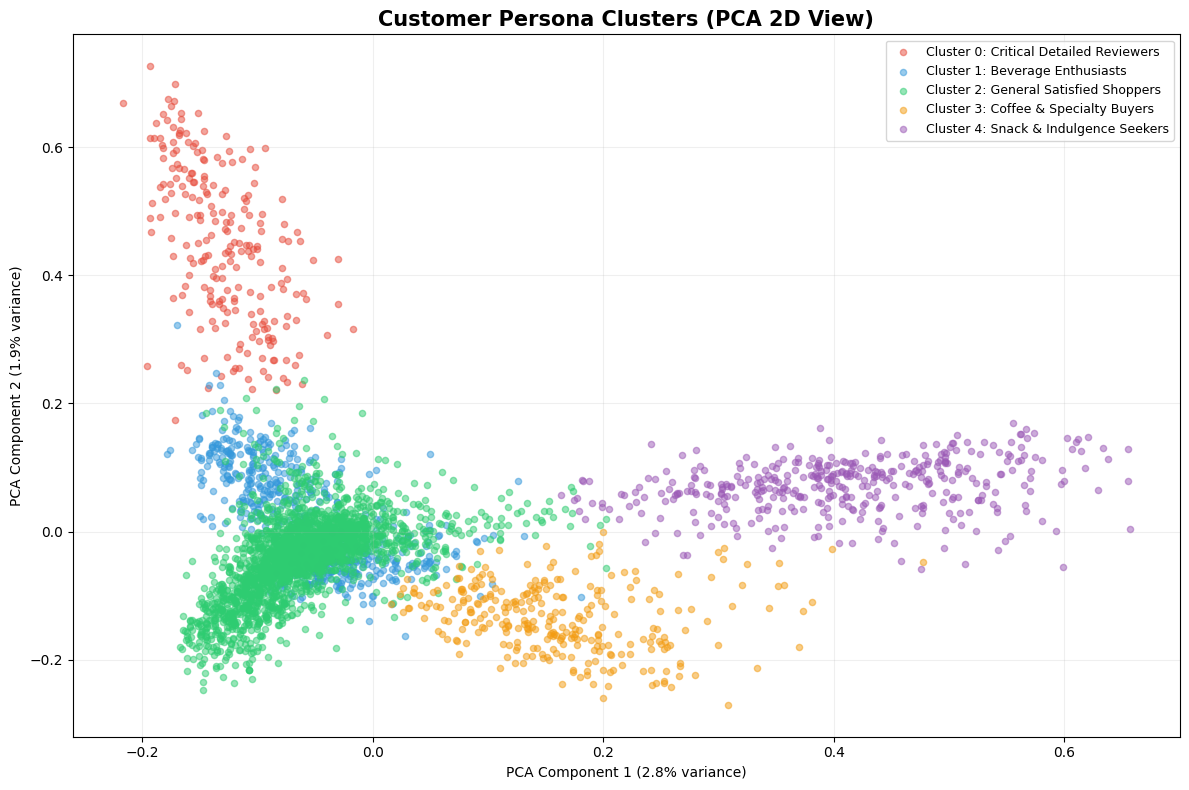

✅ Saved: cluster_scatter.png


In [17]:
# ── PCA dimensionality reduction for visualization ────────────────────────────
print("Running PCA... ⏳")
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(tfidf_matrix.toarray())

df['pca_x'] = coords[:, 0]
df['pca_y'] = coords[:, 1]

# ── Plot ──────────────────────────────────────────────────────────────────────
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']
fig, ax = plt.subplots(figsize=(12, 8))

for cluster_id, persona in persona_names.items():
    mask = df['cluster'] == cluster_id
    ax.scatter(
        df.loc[mask, 'pca_x'],
        df.loc[mask, 'pca_y'],
        c=colors[cluster_id],
        label=f"Cluster {cluster_id}: {persona}",
        alpha=0.5,
        s=20
    )

ax.set_title('Customer Persona Clusters (PCA 2D View)', fontsize=15, fontweight='bold')
ax.set_xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('cluster_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: cluster_scatter.png")

In [18]:
# ── Save Phase 2 outputs ──────────────────────────────────────────────────────
import pickle

# Save the enriched dataframe (now has cluster, persona, dominant_topic columns)
df.to_csv('reviews_clustered.csv', index=False)

# Save models for reference
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

with open('lda_model.pkl', 'wb') as f:
    pickle.dump(lda, f)

# Save LDA output probabilities
np.save('lda_output.npy', lda_output)

print("✅ Phase 2 complete! Saved:")
print("  • reviews_clustered.csv  ← main file for Phase 3")
print("  • kmeans_model.pkl")
print("  • lda_model.pkl")
print("  • lda_output.npy")
print(f"\nNew columns added to df: {['cluster', 'persona', 'dominant_topic', 'topic_name', 'pca_x', 'pca_y']}")
print(f"\nPersona breakdown:")
print(df['persona'].value_counts())

✅ Phase 2 complete! Saved:
  • reviews_clustered.csv  ← main file for Phase 3
  • kmeans_model.pkl
  • lda_model.pkl
  • lda_output.npy

New columns added to df: ['cluster', 'persona', 'dominant_topic', 'topic_name', 'pca_x', 'pca_y']

Persona breakdown:
persona
General Satisfied Shoppers     2559
Beverage Enthusiasts            518
Snack & Indulgence Seekers      405
Coffee & Specialty Buyers       294
Critical Detailed Reviewers     224
Name: count, dtype: int64


In [19]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter
import pickle
import warnings
warnings.filterwarnings('ignore')

# Install wordcloud if not already done
!pip install wordcloud vaderSentiment --quiet

from wordcloud import WordCloud
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# ── Load Phase 2 outputs ──────────────────────────────────────────────────────
df = pd.read_csv('reviews_clustered.csv')

with open('tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)
with open('kmeans_model.pkl', 'rb') as f:
    kmeans = pickle.load(f)

persona_names = {
    0: "Critical Detailed Reviewers",
    1: "Beverage Enthusiasts",
    2: "General Satisfied Shoppers",
    3: "Coffee & Specialty Buyers",
    4: "Snack & Indulgence Seekers"
}

persona_colors = {
    "Critical Detailed Reviewers":  "#E74C3C",   # red — dissatisfied
    "Beverage Enthusiasts":         "#3498DB",   # blue — calm/loyal
    "General Satisfied Shoppers":   "#2ECC71",   # green — positive majority
    "Coffee & Specialty Buyers":    "#F39C12",   # amber — specific preference
    "Snack & Indulgence Seekers":   "#9B59B6"    # purple — indulgent
}

print("✅ Phase 2 data loaded!")
print(f"Shape: {df.shape}")
print(f"\nPersonas in dataset:")
print(df['persona'].value_counts())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.6 MB/s eta 0:00:00
✅ Phase 2 data loaded!
Shape: (4000, 17)

Personas in dataset:
persona
General Satisfied Shoppers     2559
Beverage Enthusiasts            518
Snack & Indulgence Seekers      405
Coffee & Specialty Buyers       294
Critical Detailed Reviewers     224
Name: count, dtype: int64


In [20]:
# ── Run VADER on every review ─────────────────────────────────────────────────
analyzer = SentimentIntensityAnalyzer()

print("Running VADER sentiment analysis... ⏳ (takes ~30 seconds)")

# Apply to original Text (not clean_text — VADER works better with punctuation)
df['vader_compound'] = df['Text'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)
df['vader_pos']  = df['Text'].apply(lambda x: analyzer.polarity_scores(str(x))['pos'])
df['vader_neg']  = df['Text'].apply(lambda x: analyzer.polarity_scores(str(x))['neg'])
df['vader_neu']  = df['Text'].apply(lambda x: analyzer.polarity_scores(str(x))['neu'])

# Classify using standard VADER thresholds
def vader_label(score):
    if score >= 0.05:   return 'Positive'
    elif score <= -0.05: return 'Negative'
    else:                return 'Neutral'

df['vader_label'] = df['vader_compound'].apply(vader_label)

print("✅ VADER complete!\n")
print("Avg VADER compound score per persona:")
sentiment_summary = df.groupby('persona')['vader_compound'].mean().round(3).sort_values()
print(sentiment_summary)

Running VADER sentiment analysis... ⏳ (takes ~30 seconds)
✅ VADER complete!

Avg VADER compound score per persona:
persona
General Satisfied Shoppers     0.627
Coffee & Specialty Buyers      0.681
Beverage Enthusiasts           0.710
Critical Detailed Reviewers    0.753
Snack & Indulgence Seekers     0.774
Name: vader_compound, dtype: float64


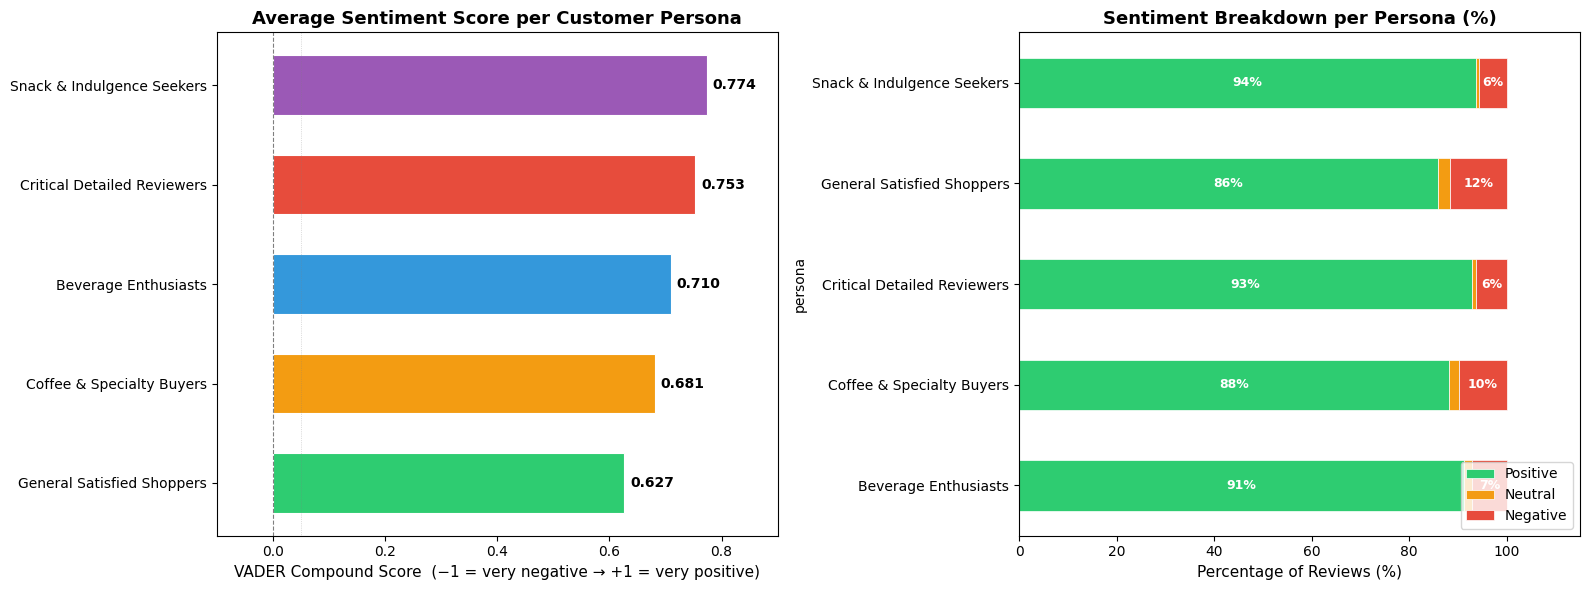

✅ Saved: phase3_sentiment.png


In [21]:
# ── Chart 1: VADER sentiment per persona ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Average compound score (bar chart)
avg_scores = df.groupby('persona')['vader_compound'].mean().sort_values()
colors_ordered = [persona_colors[p] for p in avg_scores.index]

bars = axes[0].barh(avg_scores.index, avg_scores.values, color=colors_ordered,
                     edgecolor='white', linewidth=0.8, height=0.6)

axes[0].axvline(x=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
axes[0].axvline(x=0.05, color='gray', linewidth=0.5, linestyle=':', alpha=0.5)
axes[0].set_xlabel('VADER Compound Score  (−1 = very negative → +1 = very positive)',
                    fontsize=11)
axes[0].set_title('Average Sentiment Score per Customer Persona', fontsize=13,
                   fontweight='bold')
axes[0].set_xlim(-0.1, 0.9)

# Add value labels on bars
for bar, val in zip(bars, avg_scores.values):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

# Right: Stacked % sentiment breakdown (Positive / Neutral / Negative)
sentiment_pct = df.groupby(['persona', 'vader_label']).size().unstack(fill_value=0)
sentiment_pct = sentiment_pct.div(sentiment_pct.sum(axis=1), axis=0) * 100

# Reorder columns
for col in ['Positive', 'Neutral', 'Negative']:
    if col not in sentiment_pct.columns:
        sentiment_pct[col] = 0
sentiment_pct = sentiment_pct[['Positive', 'Neutral', 'Negative']]

sentiment_pct.plot(
    kind='barh', stacked=True, ax=axes[1],
    color=['#2ECC71', '#F39C12', '#E74C3C'],
    edgecolor='white', linewidth=0.5
)
axes[1].set_xlabel('Percentage of Reviews (%)', fontsize=11)
axes[1].set_title('Sentiment Breakdown per Persona (%)', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=10)
axes[1].set_xlim(0, 115)

# Add % labels
for i, (idx, row) in enumerate(sentiment_pct.iterrows()):
    cumsum = 0
    for col, color in zip(['Positive','Neutral','Negative'],['#2ECC71','#F39C12','#E74C3C']):
        val = row[col]
        if val > 5:
            axes[1].text(cumsum + val/2, i, f'{val:.0f}%',
                        ha='center', va='center', fontsize=9,
                        color='white', fontweight='bold')
        cumsum += val

plt.tight_layout()
plt.savefig('phase3_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: phase3_sentiment.png")

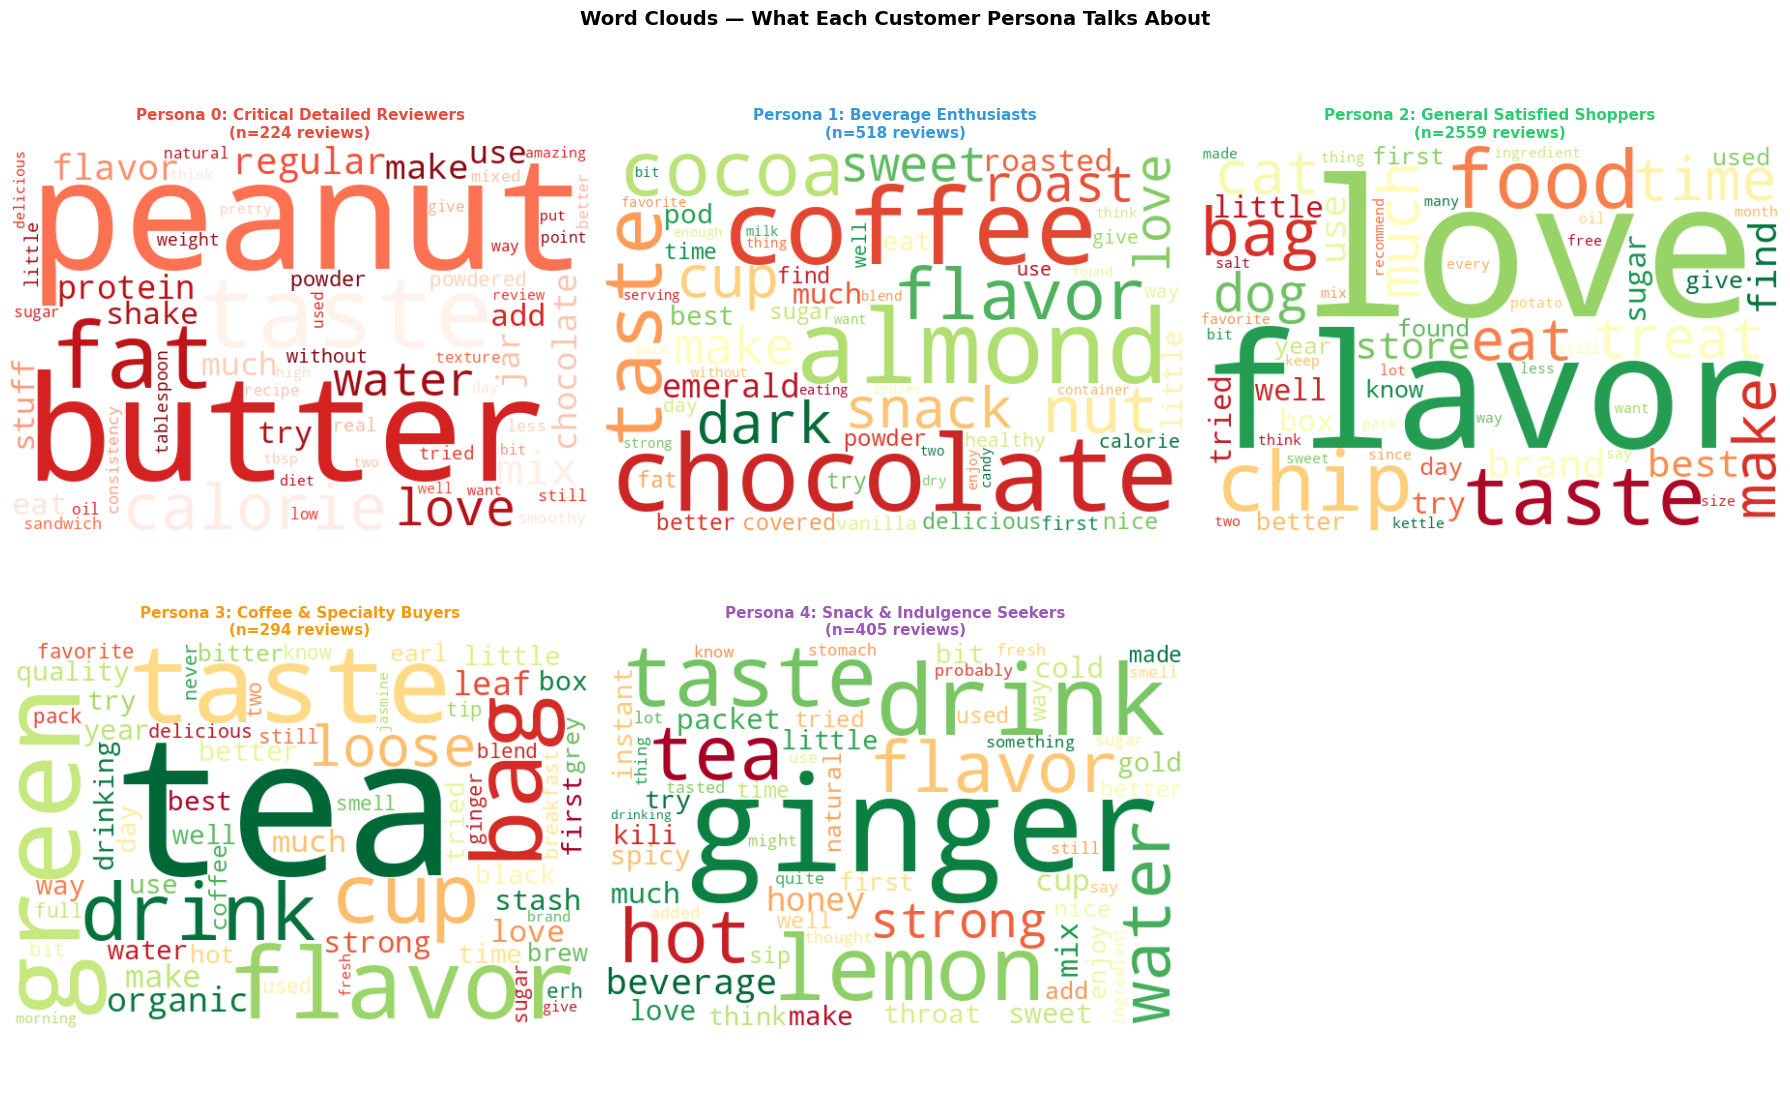

✅ Saved: phase3_wordclouds.png


In [22]:
# ── Word Clouds per persona ───────────────────────────────────────────────────

# Extra stopwords to clean up word clouds (very common words that add no meaning)
wc_stopwords = {
    'product', 'amazon', 'one', 'would', 'could', 'really', 'also',
    'even', 'this', 'that', 'they', 'them', 'have', 'with', 'just',
    'very', 'from', 'will', 'get', 'got', 'its', 'not', 'but', 'was',
    'are', 'it', 'the', 'and', 'for', 'you', 'good', 'great', 'like'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

persona_order = [
    "Critical Detailed Reviewers",
    "Beverage Enthusiasts",
    "General Satisfied Shoppers",
    "Coffee & Specialty Buyers",
    "Snack & Indulgence Seekers"
]

for idx, persona in enumerate(persona_order):
    # Combine all clean text for this persona
    persona_text = ' '.join(df[df['persona'] == persona]['clean_text'].tolist())

    wc = WordCloud(
        width=600,
        height=400,
        background_color='white',
        stopwords=wc_stopwords,
        colormap='RdYlGn' if persona != "Critical Detailed Reviewers" else 'Reds',
        max_words=60,
        min_font_size=10,
        collocations=False    # avoids duplicate phrases
    ).generate(persona_text)

    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(
        f'Persona {idx}: {persona}\n(n={df[df["persona"]==persona].shape[0]} reviews)',
        fontsize=11, fontweight='bold',
        color=persona_colors[persona]
    )
    axes[idx].axis('off')

# Hide the 6th subplot (we only have 5 personas)
axes[5].axis('off')

plt.suptitle('Word Clouds — What Each Customer Persona Talks About',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('phase3_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: phase3_wordclouds.png")

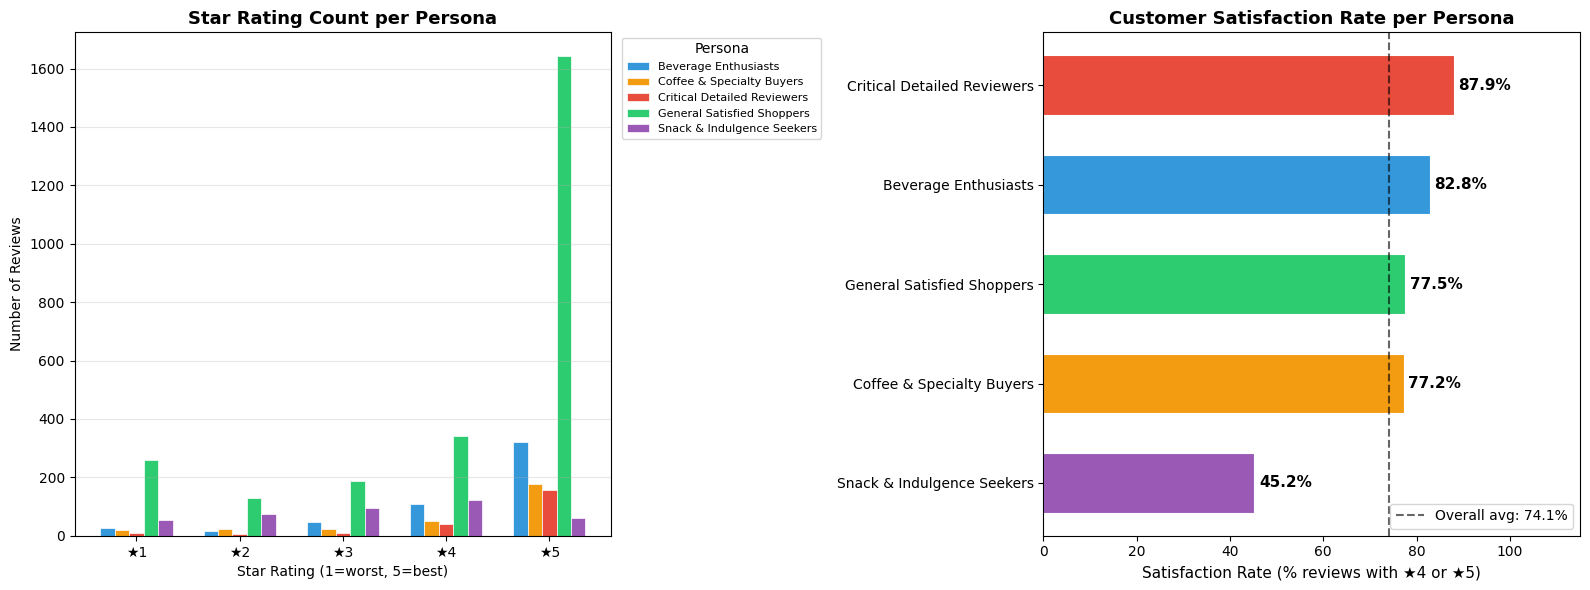

✅ Saved: phase3_ratings.png


In [23]:
# ── Star rating distribution (grouped bar chart) ──────────────────────────────
score_dist = df.groupby(['persona', 'Score']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: grouped bar chart
score_dist.T.plot(
    kind='bar', ax=axes[0],
    color=[persona_colors[p] for p in score_dist.index],
    edgecolor='white', linewidth=0.5, width=0.7
)
axes[0].set_title('Star Rating Count per Persona', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Star Rating (1=worst, 5=best)')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_xticklabels(['★1', '★2', '★3', '★4', '★5'], rotation=0)
axes[0].legend(title='Persona', fontsize=8, bbox_to_anchor=(1.01, 1))
axes[0].grid(axis='y', alpha=0.3)

# Right: Satisfaction rate (% reviews with Score >= 4)
df['is_satisfied'] = df['Score'] >= 4
sat_rate = df.groupby('persona')['is_satisfied'].mean().sort_values() * 100
colors_sat = [persona_colors[p] for p in sat_rate.index]

bars = axes[1].barh(sat_rate.index, sat_rate.values,
                     color=colors_sat, edgecolor='white', linewidth=0.8, height=0.6)

axes[1].set_xlabel('Satisfaction Rate (% reviews with ★4 or ★5)', fontsize=11)
axes[1].set_title('Customer Satisfaction Rate per Persona', fontsize=13, fontweight='bold')
axes[1].axvline(x=sat_rate.mean(), color='black', linestyle='--', alpha=0.6,
                label=f'Overall avg: {sat_rate.mean():.1f}%')
axes[1].legend(fontsize=10)
axes[1].set_xlim(0, 115)

for bar, val in zip(bars, sat_rate.values):
    axes[1].text(val + 1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('phase3_ratings.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: phase3_ratings.png")

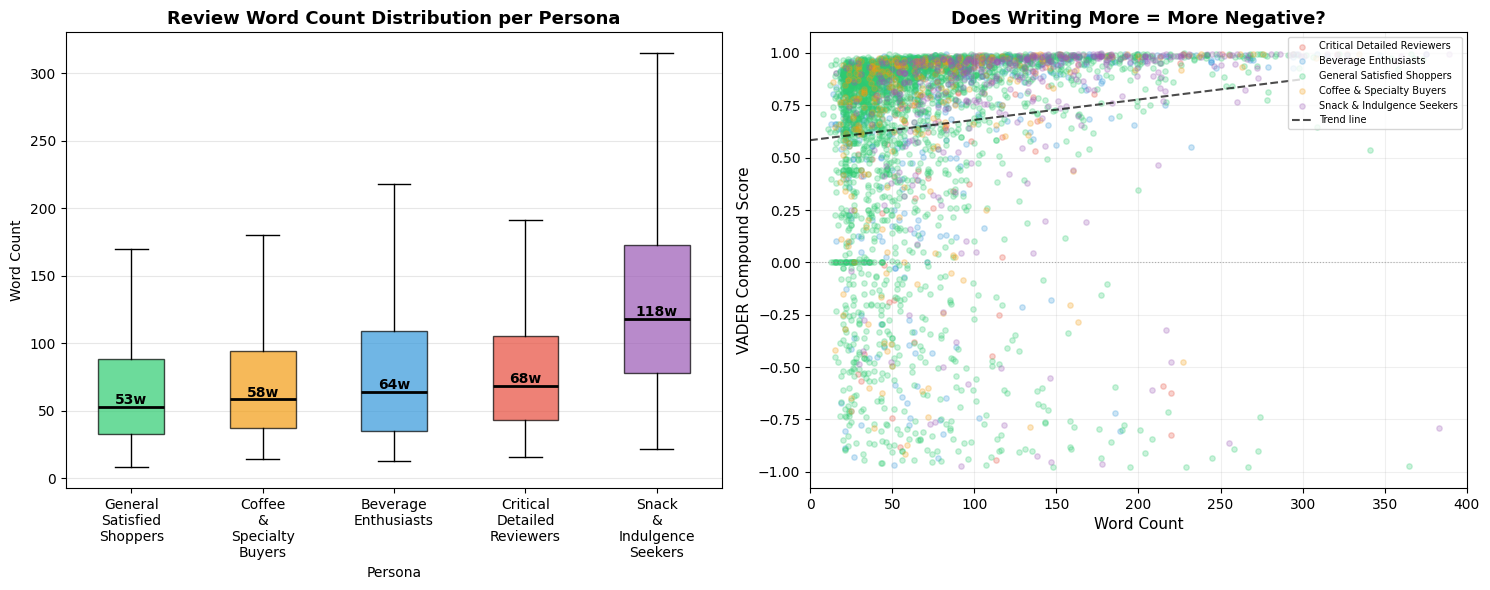

✅ Saved: phase3_behavior.png


In [24]:
# ── Reviewer behavior: how much do they write? ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Box plot of word count per persona
persona_order_sorted = df.groupby('persona')['word_count'].median().sort_values().index.tolist()
data_for_box = [df[df['persona'] == p]['word_count'].values for p in persona_order_sorted]
colors_box = [persona_colors[p] for p in persona_order_sorted]

bp = axes[0].boxplot(
    data_for_box,
    labels=[p.replace(' ', '\n') for p in persona_order_sorted],
    patch_artist=True,
    showfliers=False,    # hide extreme outliers for cleaner chart
    medianprops=dict(color='black', linewidth=2)
)
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_title('Review Word Count Distribution per Persona', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Word Count')
axes[0].set_xlabel('Persona')
axes[0].grid(axis='y', alpha=0.3)

# Add median labels on top of each box
for i, (med, p) in enumerate(zip(
    [np.median(d) for d in data_for_box], persona_order_sorted
)):
    axes[0].text(i+1, med + 2, f'{med:.0f}w', ha='center', fontsize=10,
                 fontweight='bold', color='black')

# Right: Scatter — word count vs sentiment score (colored by persona)
for persona, color in persona_colors.items():
    sub = df[df['persona'] == persona]
    axes[1].scatter(
        sub['word_count'], sub['vader_compound'],
        c=color, alpha=0.25, s=15, label=persona
    )

# Add trend line (longer reviews = more negative? let's check)
from numpy.polynomial.polynomial import polyfit
x_all = df['word_count'].values
y_all = df['vader_compound'].values
b, m = polyfit(x_all, y_all, 1)
x_line = np.linspace(0, 300, 100)
axes[1].plot(x_line, m*x_line + b, 'k--', linewidth=1.5, alpha=0.7,
             label='Trend line')

axes[1].set_xlabel('Word Count', fontsize=11)
axes[1].set_ylabel('VADER Compound Score', fontsize=11)
axes[1].set_title('Does Writing More = More Negative?', fontsize=13, fontweight='bold')
axes[1].axhline(y=0, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)
axes[1].set_xlim(0, 400)
axes[1].legend(fontsize=7, loc='upper right')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('phase3_behavior.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: phase3_behavior.png")

CUSTOMER PERSONA SUMMARY TABLE
                             Count  Avg_Score  Avg_VADER  Avg_WordCount Satisfaction
persona                                                                             
Snack & Indulgence Seekers     405       3.16       0.77         135.38        45.0%
Critical Detailed Reviewers    224       4.46       0.75          85.50        88.0%
Beverage Enthusiasts           518       4.31       0.71          87.95        83.0%
Coffee & Specialty Buyers      294       4.17       0.68          81.66        77.0%
General Satisfied Shoppers    2559       4.16       0.63          72.37        78.0%


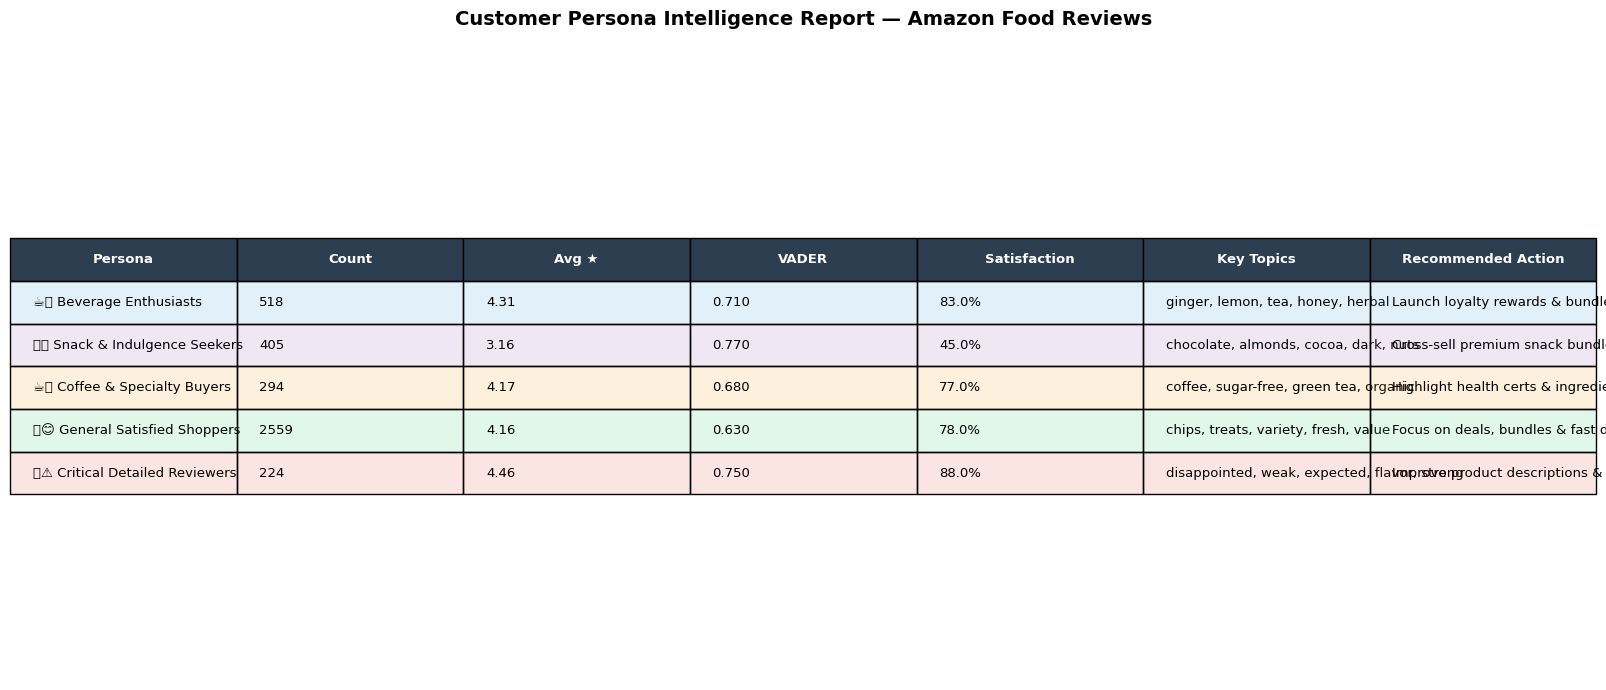

✅ Saved: phase3_persona_table.png


In [25]:
# ── Master persona summary table ──────────────────────────────────────────────
summary = df.groupby('persona').agg(
    Count          = ('Score',           'count'),
    Avg_Score      = ('Score',           'mean'),
    Avg_VADER      = ('vader_compound',  'mean'),
    Avg_WordCount  = ('word_count',      'mean'),
    Satisfaction   = ('is_satisfied',    'mean')
).round(2)

summary['Satisfaction'] = (summary['Satisfaction'] * 100).round(1).astype(str) + '%'
summary = summary.sort_values('Avg_VADER', ascending=False)

print("=" * 75)
print("CUSTOMER PERSONA SUMMARY TABLE")
print("=" * 75)
print(summary.to_string())
print("=" * 75)

# ── Plot the summary as a visual table ────────────────────────────────────────
persona_insights = {
    "Beverage Enthusiasts": {
        "icon": "☕🍵",
        "keywords": "ginger, lemon, tea, honey, herbal",
        "tone": "Enthusiastic & loyal",
        "action": "Launch loyalty rewards & bundle offers"
    },
    "Snack & Indulgence Seekers": {
        "icon": "🍫🥜",
        "keywords": "chocolate, almonds, cocoa, dark, nuts",
        "tone": "Indulgent & brand-loyal",
        "action": "Cross-sell premium snack bundles"
    },
    "Coffee & Specialty Buyers": {
        "icon": "☕🧘",
        "keywords": "coffee, sugar-free, green tea, organic",
        "tone": "Health-conscious & specific",
        "action": "Highlight health certs & ingredients"
    },
    "General Satisfied Shoppers": {
        "icon": "🛒😊",
        "keywords": "chips, treats, variety, fresh, value",
        "tone": "Broadly positive, price-sensitive",
        "action": "Focus on deals, bundles & fast delivery"
    },
    "Critical Detailed Reviewers": {
        "icon": "📝⚠️",
        "keywords": "disappointed, weak, expected, flavor, strong",
        "tone": "Analytical, high expectations",
        "action": "Improve product descriptions & quality"
    }
}

fig, ax = plt.subplots(figsize=(16, 7))
ax.axis('off')

col_labels = ['Persona', 'Count', 'Avg ★', 'VADER', 'Satisfaction', 'Key Topics', 'Recommended Action']
row_data = []

for persona, info in persona_insights.items():
    row = summary.loc[persona] if persona in summary.index else None
    if row is not None:
        row_data.append([
            f"{info['icon']} {persona}",
            int(row['Count']),
            f"{row['Avg_Score']:.2f}",
            f"{row['Avg_VADER']:.3f}",
            row['Satisfaction'],
            info['keywords'],
            info['action']
        ])

table = ax.table(
    cellText=row_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='left'
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1.2, 2.2)

# Style header row
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2C3E50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Style persona rows with their colors
for i, persona in enumerate(persona_insights.keys()):
    color = persona_colors.get(persona, '#FFFFFF')
    # Lighten the color for row background
    for j in range(len(col_labels)):
        table[i+1, j].set_facecolor(color + '25')  # 25 = ~15% opacity hex

ax.set_title('Customer Persona Intelligence Report — Amazon Food Reviews',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('phase3_persona_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: phase3_persona_table.png")

In [26]:
# ── Save Phase 3 complete dataframe ──────────────────────────────────────────
df.to_csv('reviews_final.csv', index=False)

print("✅ Phase 3 complete! Final file saved: reviews_final.csv")
print(f"\nColumns in final dataframe:")
print(df.columns.tolist())

print(f"\n📊 All charts saved:")
charts = [
    'phase3_sentiment.png     → VADER scores + sentiment breakdown',
    'phase3_wordclouds.png    → Word clouds for all 5 personas',
    'phase3_ratings.png       → Star ratings + satisfaction rate',
    'phase3_behavior.png      → Word count + correlation with sentiment',
    'phase3_persona_table.png → Master summary table for presentation'
]
for c in charts:
    print(f"  • {c}")

✅ Phase 3 complete! Final file saved: reviews_final.csv

Columns in final dataframe:
['Id', 'ProductId', 'UserId', 'ProfileName', 'Score', 'Summary', 'Text', 'clean_text', 'review_length', 'word_count', 'sentiment_label', 'cluster', 'persona', 'dominant_topic', 'topic_name', 'pca_x', 'pca_y', 'vader_compound', 'vader_pos', 'vader_neg', 'vader_neu', 'vader_label', 'is_satisfied']

📊 All charts saved:
  • phase3_sentiment.png     → VADER scores + sentiment breakdown
  • phase3_wordclouds.png    → Word clouds for all 5 personas
  • phase3_ratings.png       → Star ratings + satisfaction rate
  • phase3_behavior.png      → Word count + correlation with sentiment
  • phase3_persona_table.png → Master summary table for presentation


In [27]:
# app.py
import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import datetime

# -------------------------------
# CONFIG & STYLING
# -------------------------------
st.set_page_config(page_title="Customer Persona Intelligence Platform (NLP-Based)", layout="wide")

CUSTOM_CSS = """
<style>
/* Navbar */
.navbar {
    background-color: #131921;
    padding: 10px;
    display: flex;
    justify-content: space-between;
    align-items: center;
    color: white;
}
.navbar-title {
    font-size: 20px;
    font-weight: bold;
}
.navbar-search {
    flex-grow: 1;
    margin: 0 20px;
}
.navbar-profile {
    display: flex;
    align-items: center;
}
.navbar-profile img {
    border-radius: 50%;
    width: 30px;
    margin-right: 10px;
}

/* Sidebar */
[data-testid="stSidebar"] {
    background-color: #f5f5f5;
}

/* KPI Cards */
.kpi-card {
    background-color: white;
    padding: 20px;
    border-radius: 10px;
    box-shadow: 2px 2px 8px rgba(0,0,0,0.1);
    text-align: center;
    margin: 10px;
}
.kpi-value {
    font-size: 24px;
    font-weight: bold;
}
.kpi-label {
    font-size: 14px;
    color: #555;
}

/* Carousel */
.carousel-container {
    display: flex;
    overflow-x: auto;
    scroll-behavior: smooth;
    animation: scroll-left 20s linear infinite;
}
.carousel-card {
    flex: 0 0 auto;
    background: white;
    border-radius: 10px;
    box-shadow: 2px 2px 8px rgba(0,0,0,0.1);
    margin: 10px;
    width: 200px;
    text-align: center;
    transition: transform 0.3s;
}
.carousel-card:hover {
    transform: scale(1.05);
}
.carousel-card img {
    width: 100%;
    border-radius: 10px 10px 0 0;
}
@keyframes scroll-left {
    0% { transform: translateX(0); }
    100% { transform: translateX(-50%); }
}
</style>
"""
st.markdown(CUSTOM_CSS, unsafe_allow_html=True)

# -------------------------------
# DATA (Assume df and reduced are preloaded)
# -------------------------------
# Example placeholder if df not provided
try:
    df
except NameError:
    df = pd.DataFrame({
        "review_text": ["Great product!", "Not worth it", "Average quality", "Loved it"],
        "clean_text": ["great product", "not worth", "average quality", "loved"],
        "rating": [5, 1, 3, 5],
        "sentiment": ["Positive", "Negative", "Neutral", "Positive"],
        "cluster": [0, 2, 1, 3]
    })
try:
    reduced
except NameError:
    import numpy as np
    reduced = np.random.rand(len(df), 2)

persona_map = {
    0: "Budget Buyers",
    1: "Quality Seekers",
    2: "Dissatisfied Users",
    3: "Loyal Customers"
}

# -------------------------------
# NAVBAR
# -------------------------------
with st.container():
    st.markdown(f"""
    <div class="navbar">
        <div class="navbar-title">Customer Persona Intelligence Platform</div>
        <div class="navbar-search"><input type="text" placeholder="Search..." style="width:100%;padding:5px;border-radius:5px;"></div>
        <div class="navbar-profile">
            <img src="https://via.placeholder.com/30" />
            <span>Gobinda</span>
        </div>
        <div>{datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")} | Marpalli, TG, India</div>
    </div>
    """, unsafe_allow_html=True)

# -------------------------------
# SIDEBAR NAVIGATION
# -------------------------------
page = st.sidebar.radio("Navigation", ["Home", "Analytics", "Personas", "AI Assistant"])

# -------------------------------
# HOME PAGE
# -------------------------------
if page == "Home":
    col1, col2, col3 = st.columns(3)
    with col1:
        st.markdown(
            f'<div class="kpi-card"><div class="kpi-value">{len(df)}</div><div class="kpi-label">Total Customers</div></div>',
            unsafe_allow_html=True
        )
    with col2:
        pos_pct = (df['sentiment'].eq("Positive").mean() * 100)
        st.markdown(
            f'<div class="kpi-card"><div class="kpi-value">{pos_pct:.1f}%</div><div class="kpi-label">Positive Sentiment</div></div>',
            unsafe_allow_html=True
        )
    with col3:
        clusters = df['cluster'].nunique()
        st.markdown(
            f'<div class="kpi-card"><div class="kpi-value">{clusters}</div><div class="kpi-label">Number of Clusters</div></div>',
            unsafe_allow_html=True
        )

    st.subheader("Cluster Distribution")
    cluster_counts = df['cluster'].value_counts().reset_index()
    cluster_counts.columns = ["cluster", "count"]

    fig = px.bar(
        cluster_counts,
        x="cluster",
        y="count",
        color="cluster",
        labels={"cluster": "Cluster", "count": "Count"}
    )
    st.plotly_chart(fig, use_container_width=True)

    st.subheader("Sentiment Distribution")
    sentiment_counts = df.groupby(["cluster", "sentiment"]).size().reset_index(name="count")
    fig2 = px.bar(
        sentiment_counts,
        x="cluster",
        y="count",
        color="sentiment",
        barmode="stack",
        labels={"cluster": "Cluster", "count": "Count"}
    )
    st.plotly_chart(fig2, use_container_width=True)


# -------------------------------
# ANALYTICS PAGE
# -------------------------------
elif page == "Analytics":
    st.subheader("PCA Scatter Plot")
    fig = px.scatter(x=reduced[:,0], y=reduced[:,1], color=df['cluster'].astype(str), labels={'x':'PC1','y':'PC2'})
    st.plotly_chart(fig, use_container_width=True)

    st.subheader("Top Keywords per Cluster")
    for c in df['cluster'].unique():
        st.markdown(f"**Cluster {c} - {persona_map.get(c,'Unknown')}**")
        # Placeholder keywords
        st.info("Keywords: product, price, quality, service")

# -------------------------------
# PERSONAS PAGE
# -------------------------------
elif page == "Personas":
    cluster_choice = st.selectbox("Select Cluster", df['cluster'].unique())
    persona_name = persona_map.get(cluster_choice, "Unknown")
    st.header(f"Persona: {persona_name}")
    st.write("Description: This persona represents typical behavior and preferences of customers in this cluster.")
    sentiment_breakdown = df[df['cluster']==cluster_choice]['sentiment'].value_counts(normalize=True)*100
    st.write("Sentiment Breakdown:")
    st.write(sentiment_breakdown)

    st.write("Strategy Recommendation: Focus on tailored offers and engagement strategies for this persona.")

    st.subheader("WordCloud")
    text = " ".join(df[df['cluster']==cluster_choice]['clean_text'])
    wc = WordCloud(background_color="white").generate(text)
    fig, ax = plt.subplots()
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    st.pyplot(fig)

# -------------------------------
# AI ASSISTANT PAGE
# -------------------------------
elif page == "AI Assistant":
    st.subheader("AI Assistant Chat")
    if "messages" not in st.session_state:
        st.session_state.messages = []

    user_input = st.chat_input("Say something...")
    if user_input:
        st.session_state.messages.append(("user", user_input))
        # Simple rule-based responses
        if "best persona" in user_input.lower():
            response = "The best persona is Loyal Customers (Cluster 3) due to high positive sentiment."
        elif "worst cluster" in user_input.lower():
            response = "The worst cluster is Dissatisfied Users (Cluster 2) due to negative sentiment."
        elif "strategy" in user_input.lower():
            response = "Strategy suggestion: Improve service quality and offer loyalty rewards."
        else:
            response = "I'm here to help with personas and strategies."
        st.session_state.messages.append(("assistant", response))

    for role, msg in st.session_state.messages:
        if role == "user":
            st.chat_message("user").write(msg)
        else:
            st.chat_message("assistant").write(msg)

        st.subheader("Cluster Distribution")
    cluster_counts = df['cluster'].value_counts().reset_index()
    cluster_counts.columns = ["cluster", "count"]

    fig = px.bar(
        cluster_counts,
        x="cluster",
        y="count",
        color="cluster",
        labels={"cluster": "Cluster", "count": "Count"}
    )
    st.plotly_chart(fig, use_container_width=True)

    st.markdown("""
    <div class="carousel-container">
        <div class="carousel-card">
            <img src="https://via.placeholder.com/200x150" />
            <h4>Product A</h4>
            <p>$19.99</p>
        </div>
        <div class="carousel-card">
            <img src="https://via.placeholder.com/200x150" />
            <h4>Product B</h4>
            <p>$29.99</p>
        </div>
        <div class="carousel-card">
            <img src="https://via.placeholder.com/200x150" />
            <h4>Product C</h4>
            <p>$39.99</p>
        </div>
    </div>
    """, unsafe_allow_html=True)


2026-05-03 22:33:15.904 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 22:33:15.914 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 22:33:15.916 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 22:33:15.919 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 22:33:15.925 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 22:33:15.927 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 22:33:15.929 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 22:33:15.931 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar